Till now all now the models we build were based on the keras - Sequentail model
The Sequential model has certain assumptions -> i.e 1 I/P , 1 O/P, linear layers
Linear Topology

![lec_img/Linear_topology.png](lec_img/Linear_topology.png)

Let me tell you example where sequential model would fail
1) lets say we have an image dataset and we have to predict two things -> age & emotion

![lec_img/non_linear_eg_1.png](lec_img/non_linear_eg_1.png)

now this can be done using two sequential NN --> which would be very inefficient
Instead we use Non-linear model

![lec_img/non-linear_eg_2.png](lec_img/non-linear_eg_2.png)

Their can be cases with muliple inputs too 
2) An Ecommerce Platform  (with 3 diff I/P) and 1 O/P - price

![lec_img/eg_2.png](lec_img/eg_2.png)

![lec_img/eg_2_struc.png](lec_img/eg_2_struc.png)

In [1]:
# lets build a simple architecture
from keras.models import Model
from keras.layers import *

In [2]:
x = Input(shape=(3,))

In [3]:
hidden1 = Dense(128, activation='relu')(x)
hidden2 = Dense(64, activation='relu')(hidden1)

output1 = Dense(1, activation='linear')(hidden1)
output2 = Dense(1, activation='sigmoid')(hidden1)

2025-09-01 22:35:43.009597: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-09-01 22:35:43.009613: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-09-01 22:35:43.009615: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-09-01 22:35:43.009628: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-01 22:35:43.009635: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
model = Model(inputs = x, outputs =[output1, output2])

In [5]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 770 (3.01 KB)

 Trainable params: 770 (3.01 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

# test if Jupyter sees dot now
!dot -V


dot - graphviz version 13.1.2 (20250808.2320)


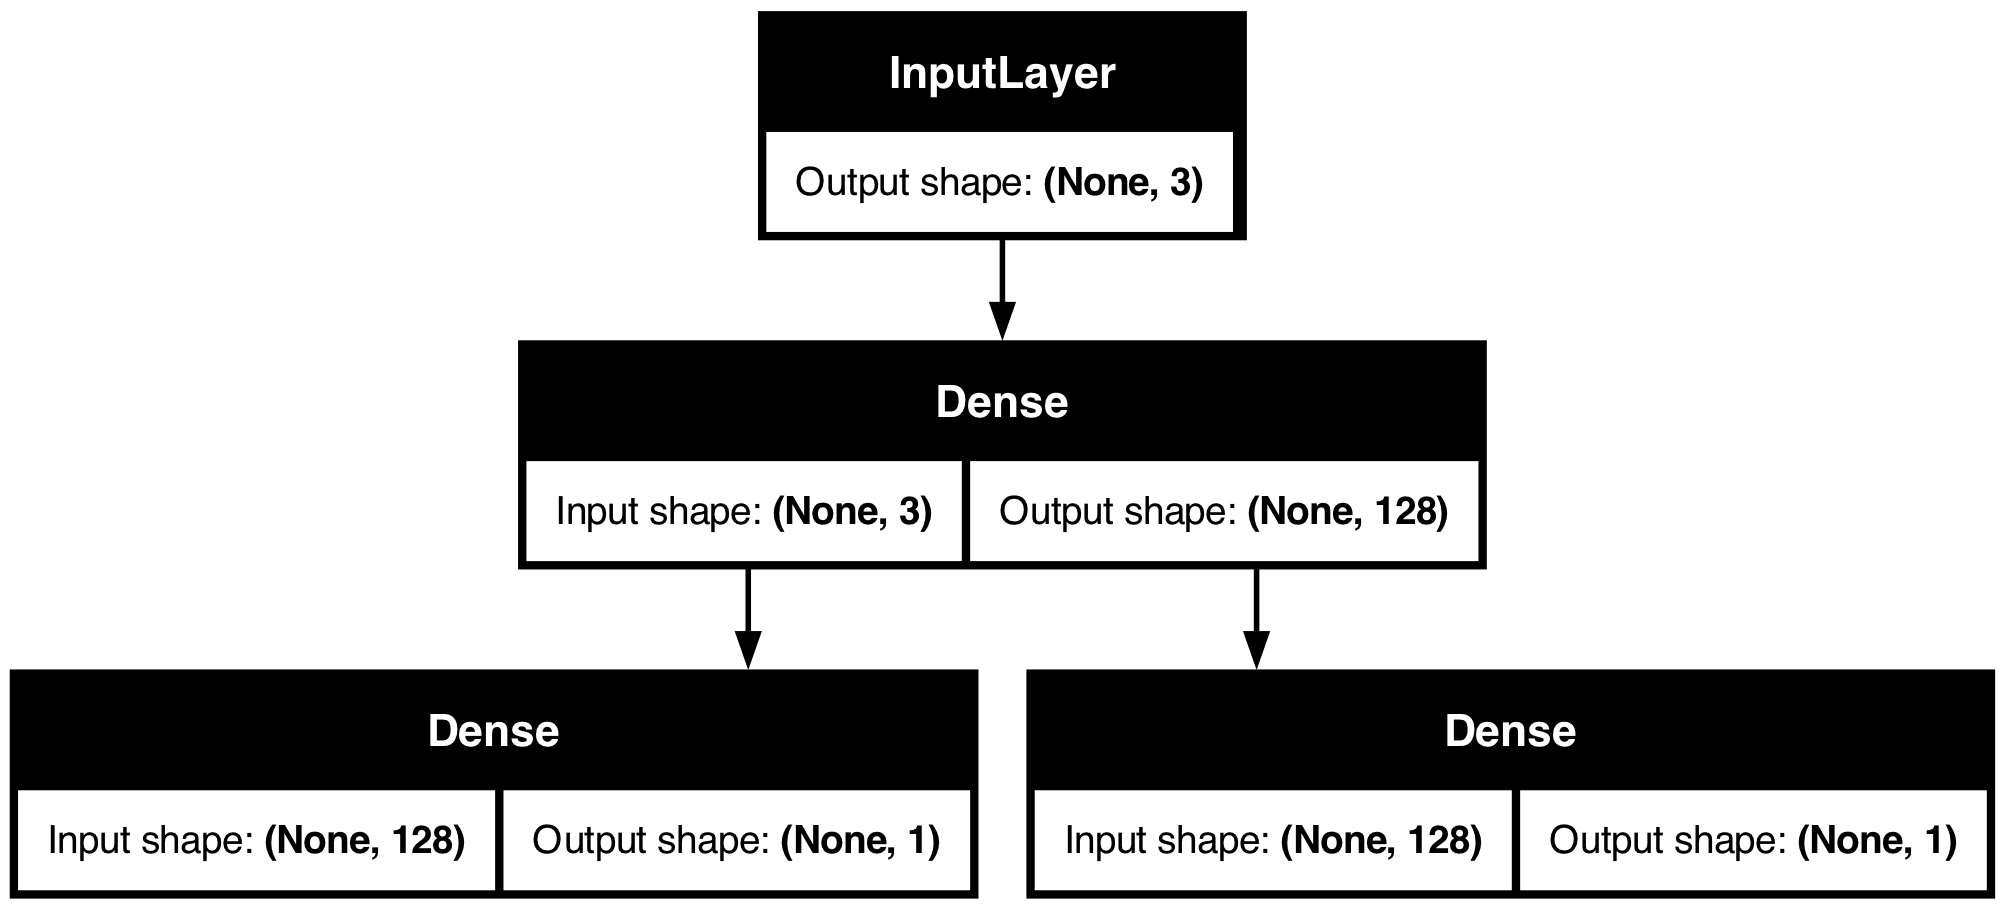

In [10]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)

In [27]:
# lets build for two diff inputs
inputA = Input(shape=(32, ))
inputB = Input(shape=(128,))

In [28]:
# the first branch operats on the first input
x = Dense(8, activation='relu')(inputA)
x1= Dense(4, activation='relu')(x)

# the second branch operates on the second input
y = Dense(64, activation='relu')(inputB)
y1 = Dense(32, activation='relu')(y)
y2 = Dense(4, activation='relu')(y1)

In [29]:
combined = concatenate([x1, y2])

In [30]:
z = Dense(2, activation='relu')(combined)
z1 = Dense(1, activation='linear')(z)

In [31]:
model = Model(inputs=[inputA, inputB], outputs=[z1])

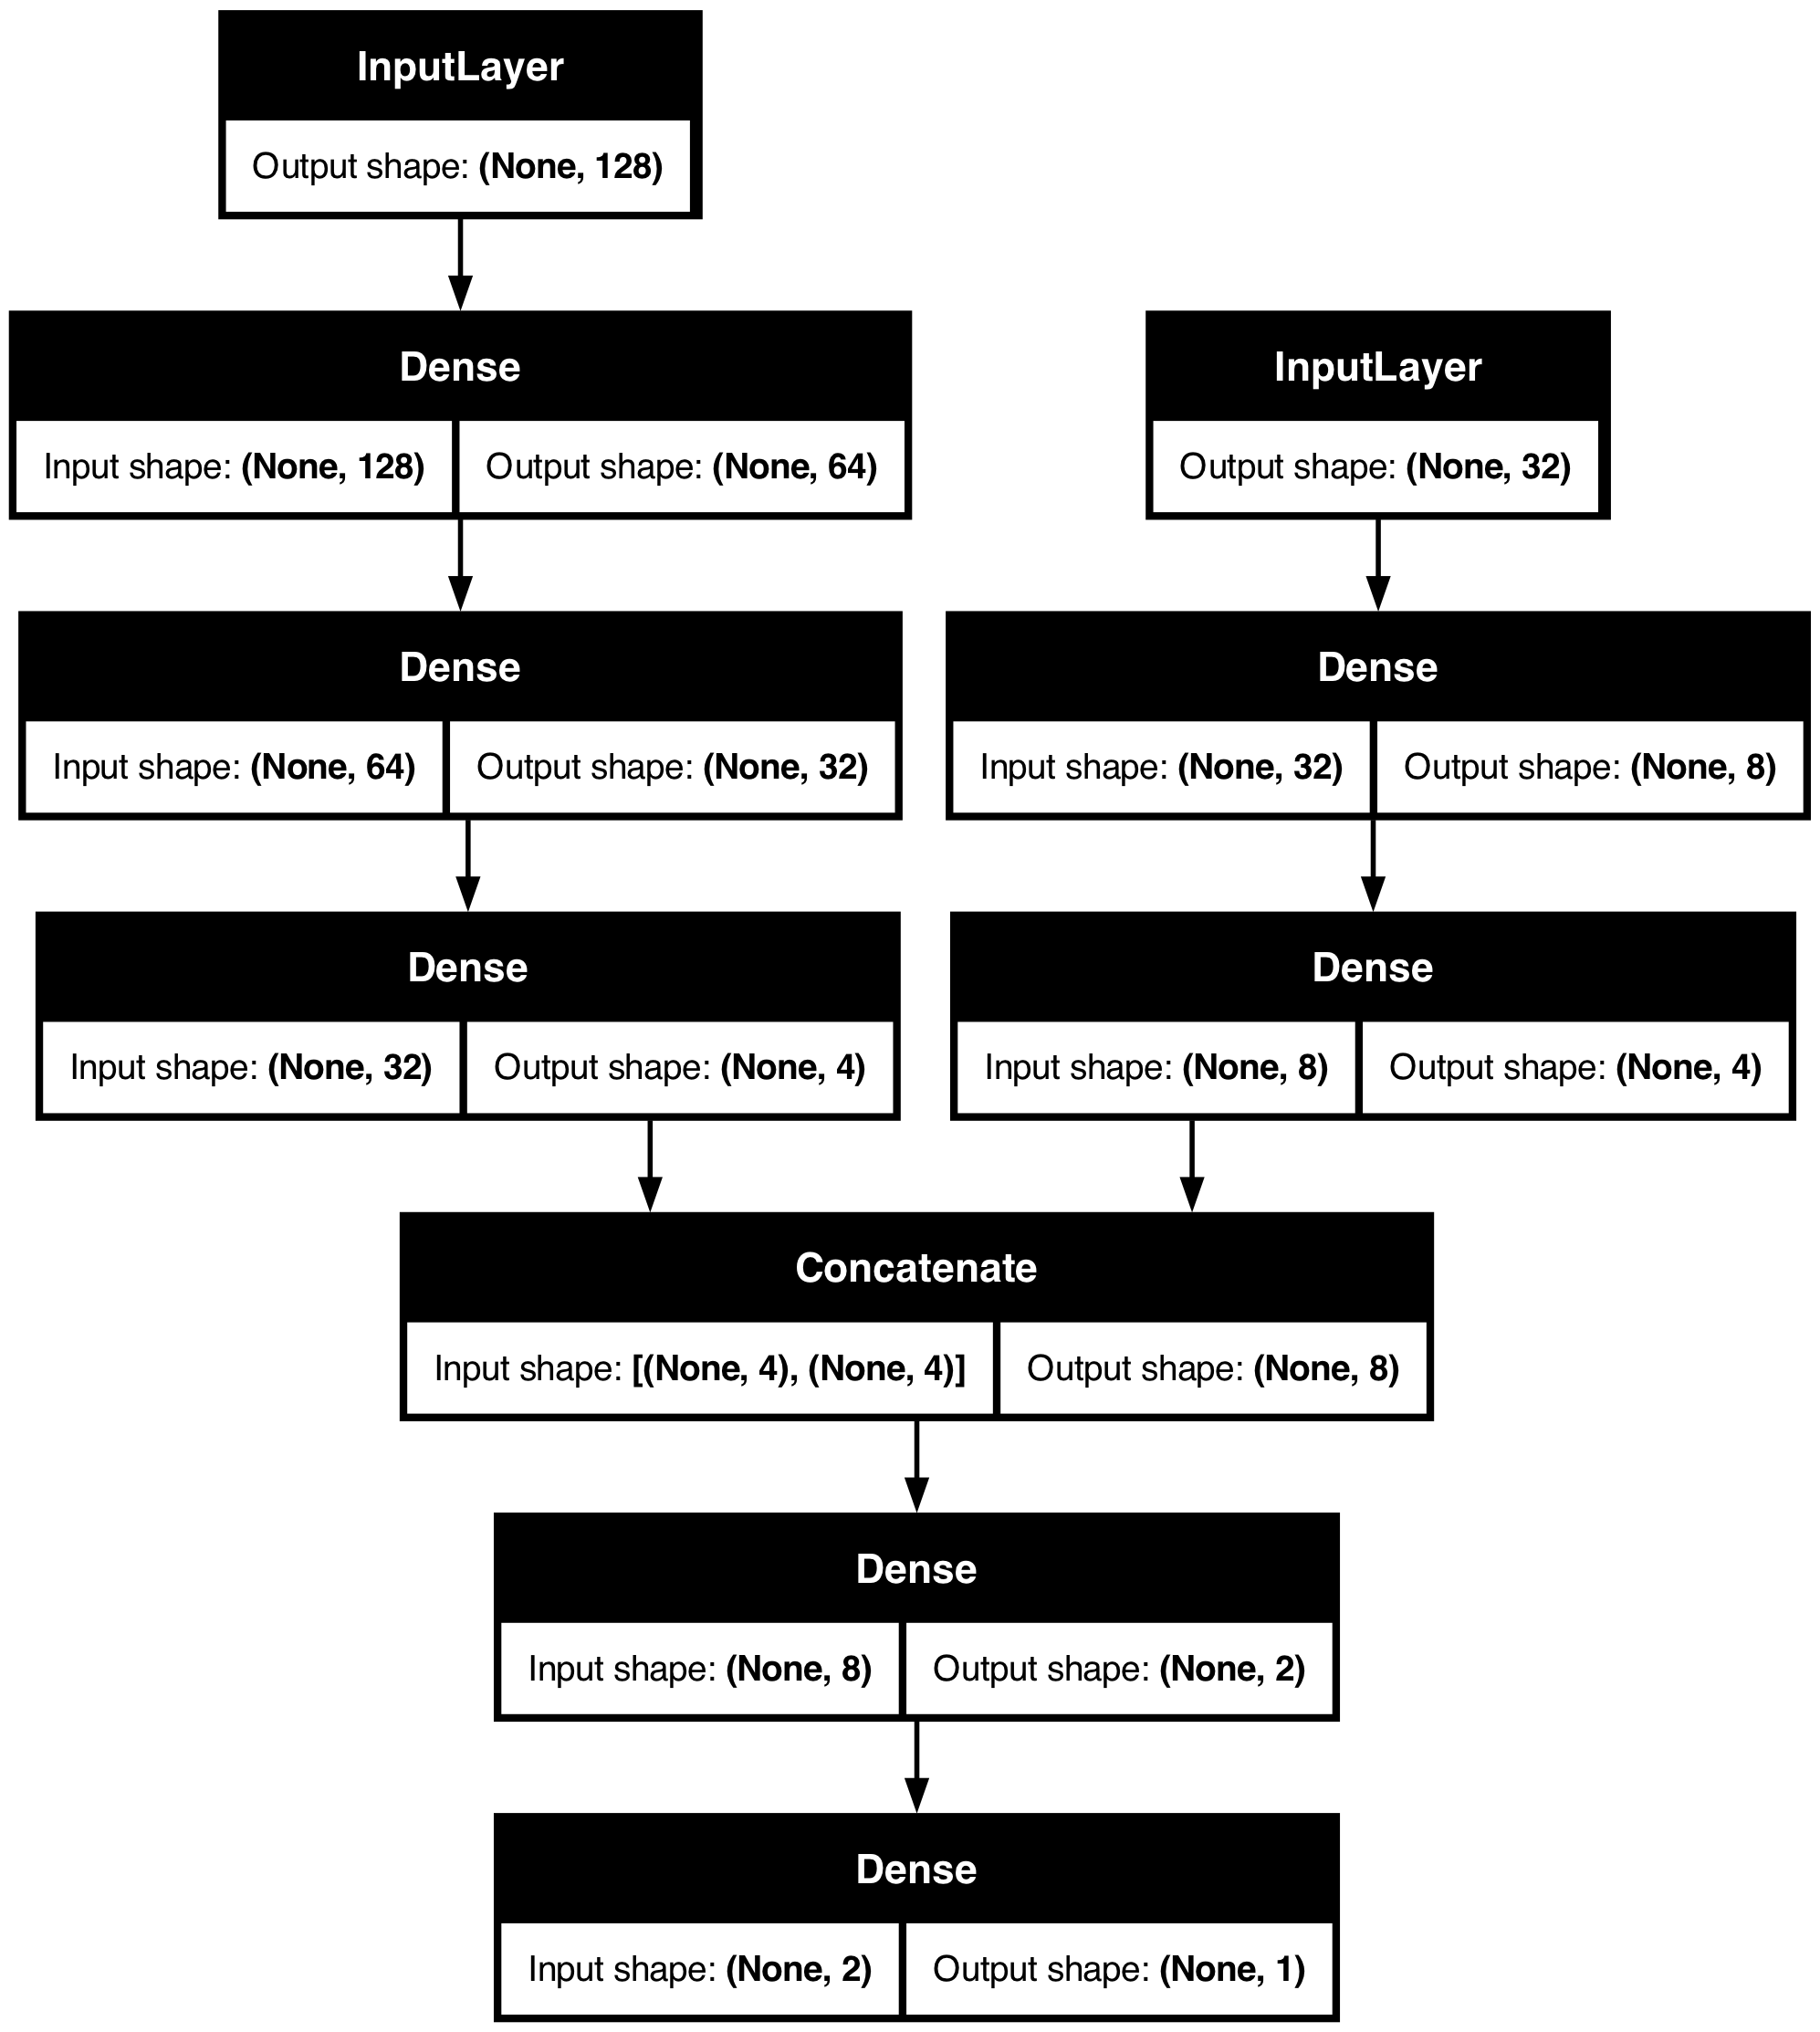

In [32]:
plot_model(model, show_shapes=True)